In [1]:
import pandas as pd
import numpy as np
import glob
import anndata as an
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

# SCENIC RESOURCES

In [2]:
# load scenic
# fpath = "/nfs/turbo/umms-indikar/shared/projects/DGC/data/processed_data/10kbp_up_10kbp_down_B.csv"
fpath = "/nfs/turbo/umms-indikar/shared/projects/DGC/data/processed_data/500bp_up_100bp_down_B.csv"
sdf = pd.read_csv(fpath)
sdf = sdf.rename(columns={'Unnamed: 0' : 'gene_name'})
sdf = sdf.set_index('gene_name')
print(f"{sdf.shape=}")
sdf.head()

sdf.shape=(27090, 1605)


,ABL1,ACAA1,ADNP,ADNP2,AEBP2,AFF4,AHCTF1,AHDC1,AHR,AHRR,...,ZSCAN32,ZSCAN4,ZSCAN5A,ZSCAN5B,ZSCAN5C,ZSCAN9,ZXDA,ZXDB,ZXDC,ZZZ3
gene_name,,,,,,,,,,,,,,,,,,,,,
A1BG,3.41,0.0,6.140,2.040,0.0,13.70,20.40,4.890000,2.696000,0.0,...,0.00,1.545,0.0,0.0869,4.64,5.5700,2.0215,2.857667,0.1015,3.54
A1BG-AS1,2.23,0.0,5.610,2.040,0.0,13.30,7.66,3.288750,0.964200,0.0,...,0.00,4.175,0.0,0.0000,1.57,1.7870,1.9600,1.640000,0.0000,1.50
A1CF,4.90,0.0,5.730,3.910,0.0,9.50,11.10,4.343750,3.388000,0.0,...,1.33,1.547,0.0,0.1720,5.30,5.4050,5.5950,4.703333,1.7500,4.74
A2M,4.78,0.0,6.880,0.564,0.0,6.99,6.32,4.982500,2.490000,0.0,...,0.00,0.000,0.0,0.0000,4.51,2.2025,5.0650,5.513334,0.3500,5.20
A2M-AS1,2.86,0.0,0.499,0.266,0.0,5.23,4.57,3.617375,0.762922,0.0,...,0.00,0.000,0.0,1.6800,1.88,1.3700,1.6400,1.406333,0.0000,4.21


X.shape=(1589, 1589)


Text(0.5, 0, 'SCENIC+ score')

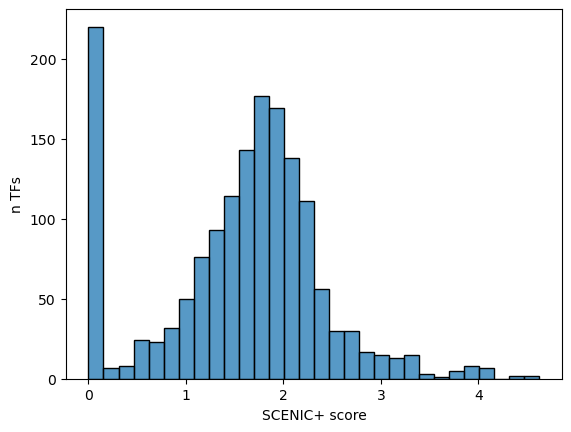

In [3]:
X = sdf[sdf.index.isin(sdf.columns)]
X = X[X.index]
print(f"{X.shape=}")
diag = np.log1p(np.diag(X))

sns.histplot(
    diag,
)

plt.ylabel('n TFs')
plt.xlabel('SCENIC+ score')

In [4]:
# build initial structure
TFs = [
    'GATA2', 'GFI1B', 'STAT5A', 'REL', 'FOS',
    'MYOD1',
]

df = pd.melt(
    sdf[TFs].reset_index(),
    id_vars='gene_name',
    var_name='TF',
    value_name='scenic_score',
)

print(f"raw {df.shape=}")
df = df[df['scenic_score'] > 0]
print(f"filtered {df.shape=}")
df = df.sort_values(by=['TF', 'scenic_score'], ascending=[True, False])
df = df.reset_index(drop=True)

df['gene_is_TF'] = df['gene_name'].isin(sdf.columns)
print()
print(df['gene_is_TF'].value_counts().to_string())
print()
df.head()

raw df.shape=(162540, 3)
filtered df.shape=(162271, 3)

gene_is_TF
False    152737
True       9534



,gene_name,TF,scenic_score,gene_is_TF
0,LOC440896,FOS,27.699244,False
1,IRAIN,FOS,26.747536,False
2,LINC00273,FOS,25.706123,False
3,PRDM16,FOS,25.701809,True
4,GGTLC1,FOS,24.037807,False


In [5]:
# paths → label mapping
files = {
    "5TF": "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/DEG/reprogram_v_control.csv",
    "MYOD": "/scratch/indikar_root/indikar1/shared_data/HYB/diff_expression/mmMYOD1_vs_control.csv",
}

#--- load & tag --------------------------------------------------------------#
combined = pd.concat(
    (pd.read_csv(path).assign(dataset=label) for label, path in files.items()),
    ignore_index=True
)

#--- standardize columns -----------------------------------------------------#
combined = combined.drop(columns=["Unnamed: 0"])
combined["group"] = combined["group"].replace({"Reprogram": "5TF", "mmMYOD1": "MYOD"})

#--- thresholds --------------------------------------------------------------#
logfoldchanges = 1.0
pvals_adj      = 0.05

# condition: keep rows that meet *all* cut-offs
keep = (
    (combined["logfoldchanges"] > logfoldchanges) &
    (combined["pvals_adj"]     < pvals_adj)
)

#--- add filter flag; no rows dropped ---------------------------------------#
combined["filter"] = keep        # True if row passes thresholds, else False

# optional: quick counts
print("\nRows passing filters:\n", combined["group"][combined["filter"]].value_counts(), "\n")
print()

# --- BJ-gene flag -----------------------------------------------------------#
cond_5tf_ctrl = (
    (combined["dataset"] == "5TF")  &
    (combined["group"]   == "Control") &
    (combined["logfoldchanges"] >  logfoldchanges) &   # ≥ +1.5
    (combined["pvals_adj"]     <  pvals_adj)           # ≤ 0.05
)

cond_myod_down = (
    (combined["dataset"] == "MYOD") &
    (combined["logfoldchanges"] < -logfoldchanges) &   # ≤ −1.5
    (combined["pvals_adj"]     <  pvals_adj)
)

combined["BJ_genes"] = cond_5tf_ctrl | cond_myod_down
# optional: quick counts
print("\nRows passing filters:\n", combined["group"][combined["BJ_genes"]].value_counts(), "\n")
print()

combined.head()


Rows passing filters:
 group
MYOD       4162
5TF        2471
Control    1838
Name: count, dtype: int64 



Rows passing filters:
 group
Control    1838
MYOD        775
Name: count, dtype: int64 




,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference,dataset,filter,BJ_genes
0,Control,IFI6,97.74686,5.784794,0.0,0.0,0.969524,0.432583,5TF,True,True
1,Control,DCN,97.74105,7.192836,0.0,0.0,0.952861,0.078667,5TF,True,True
2,Control,THBS1,95.81976,6.315111,0.0,0.0,0.949901,0.114701,5TF,True,True
3,Control,LUM,95.34439,6.772968,0.0,0.0,0.932800,0.051091,5TF,True,True
4,Control,LY6E,94.69701,2.988206,0.0,0.0,0.985201,0.692099,5TF,True,True


# add some metadata to DF

In [6]:
# add a column if the gene is observed in our datasets

df['is_observed'] = df['gene_name'].isin(combined['names'].unique())

print()
print(df['is_observed'].value_counts())
print()

# add DEG columns
for group in ['5TF', 'MYOD']:
    tmp = combined[combined['group'] == group]
    tmp = tmp[tmp['filter']]
    print(group, tmp.shape)

    fc_map = dict(zip(tmp.names.values, tmp.logfoldchanges.values))

    column_name = f"{group}_foldchange"
    df[column_name] = df['gene_name'].map(fc_map)
    

df = df.fillna(0.0)
print(f"{df.shape=}")
df.head()


is_observed
True     98574
False    63697
Name: count, dtype: int64

5TF (2471, 11)
MYOD (4162, 11)
df.shape=(162271, 7)


,gene_name,TF,scenic_score,gene_is_TF,is_observed,5TF_foldchange,MYOD_foldchange
0,LOC440896,FOS,27.699244,False,False,0.0,0.0
1,IRAIN,FOS,26.747536,False,True,0.0,0.0
2,LINC00273,FOS,25.706123,False,False,0.0,0.0
3,PRDM16,FOS,25.701809,True,True,0.0,0.0
4,GGTLC1,FOS,24.037807,False,False,0.0,0.0


In [7]:
outpath = "/scratch/indikar_root/indikar1/shared_data/for_lindsey/scenic_data.csv"
df.to_csv(outpath, index=False)
df.head()

,gene_name,TF,scenic_score,gene_is_TF,is_observed,5TF_foldchange,MYOD_foldchange
0,LOC440896,FOS,27.699244,False,False,0.0,0.0
1,IRAIN,FOS,26.747536,False,True,0.0,0.0
2,LINC00273,FOS,25.706123,False,False,0.0,0.0
3,PRDM16,FOS,25.701809,True,True,0.0,0.0
4,GGTLC1,FOS,24.037807,False,False,0.0,0.0


In [8]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)